# WRM Module 2 — Timeseries Analysis
**Ill River & Rhein River: Discharge and Suspended Sediment Concentration**

Stations:
- **Gisingen** (Ill River, Austria): Q 1976–2013 (15 min), C 2003–2021 (15 min)
- **Diepoldsau, Rietbrücke** (Rhein River, CH): Q 1984–2025 (10 min), C 2012–2025 (10 min)

In [5]:
# Global imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA = "../DATA/"
FILES = {
    "gis_Q": (DATA + "Q_Gisingen_1976-2023.csv",    "q_m3s"),
    "gis_C": (DATA + "SSC_Gisingen_2003-2020.csv",   "ssc_gL"),
    "die_Q": (DATA + "Q_Diepoldsau_m3s.csv",          "q_m3s"),
    "die_C": (DATA + "SSC_Diepoldsau_gL.csv",          "ssc_gL"),
}

---
## Section 1 — Timeseries Review
*Points: 2 | Branch: task1-review*

**Objectives:**
1. Resample all sub-hourly series to monthly means.
2. Plot Q and C for both stations over their full record length.
3. Test stationarity via linear regression (H₀: slope = 0, α = 5%).
4. Remove the mean (or significant trend) to obtain a zero-mean series z(t) with variance σ²_z.
5. Discuss whether any discharge trend reflects a physical process or measurement error.

In [6]:
# Section 1 — IMPORT
import sys, os
sys.path.insert(0, os.path.abspath("."))
from helpers import load_monthly, fit_linear_trend, detrend_series, summarise_trend

In [7]:
# Section 1 — MAIN

# 1. Load and resample to monthly means
gis_Q_monthly = load_monthly(*FILES["gis_Q"])
gis_C_monthly = load_monthly(*FILES["gis_C"])
die_Q_monthly = load_monthly(*FILES["die_Q"])
die_C_monthly = load_monthly(*FILES["die_C"])

monthly_series = {
    "Gisingen Q (m3/s)":   gis_Q_monthly,
    "Gisingen C (g/L)":    gis_C_monthly,
    "Diepoldsau Q (m3/s)": die_Q_monthly,
    "Diepoldsau C (g/L)":  die_C_monthly,
}

# 2. Fit linear trend and test significance at alpha = 5%
trends = {label: fit_linear_trend(s) for label, s in monthly_series.items()}

# 3. Detrend to zero-mean series z(t)
detrended    = {}
variances    = {}
trend_flags  = {}
for label, s in monthly_series.items():
    z, sigma2, removed      = detrend_series(s, trends[label], alpha=0.05)
    detrended[label]        = z
    variances[label]        = sigma2
    trend_flags[label]      = removed

print("Section 1 MAIN complete.")

Section 1 MAIN complete.


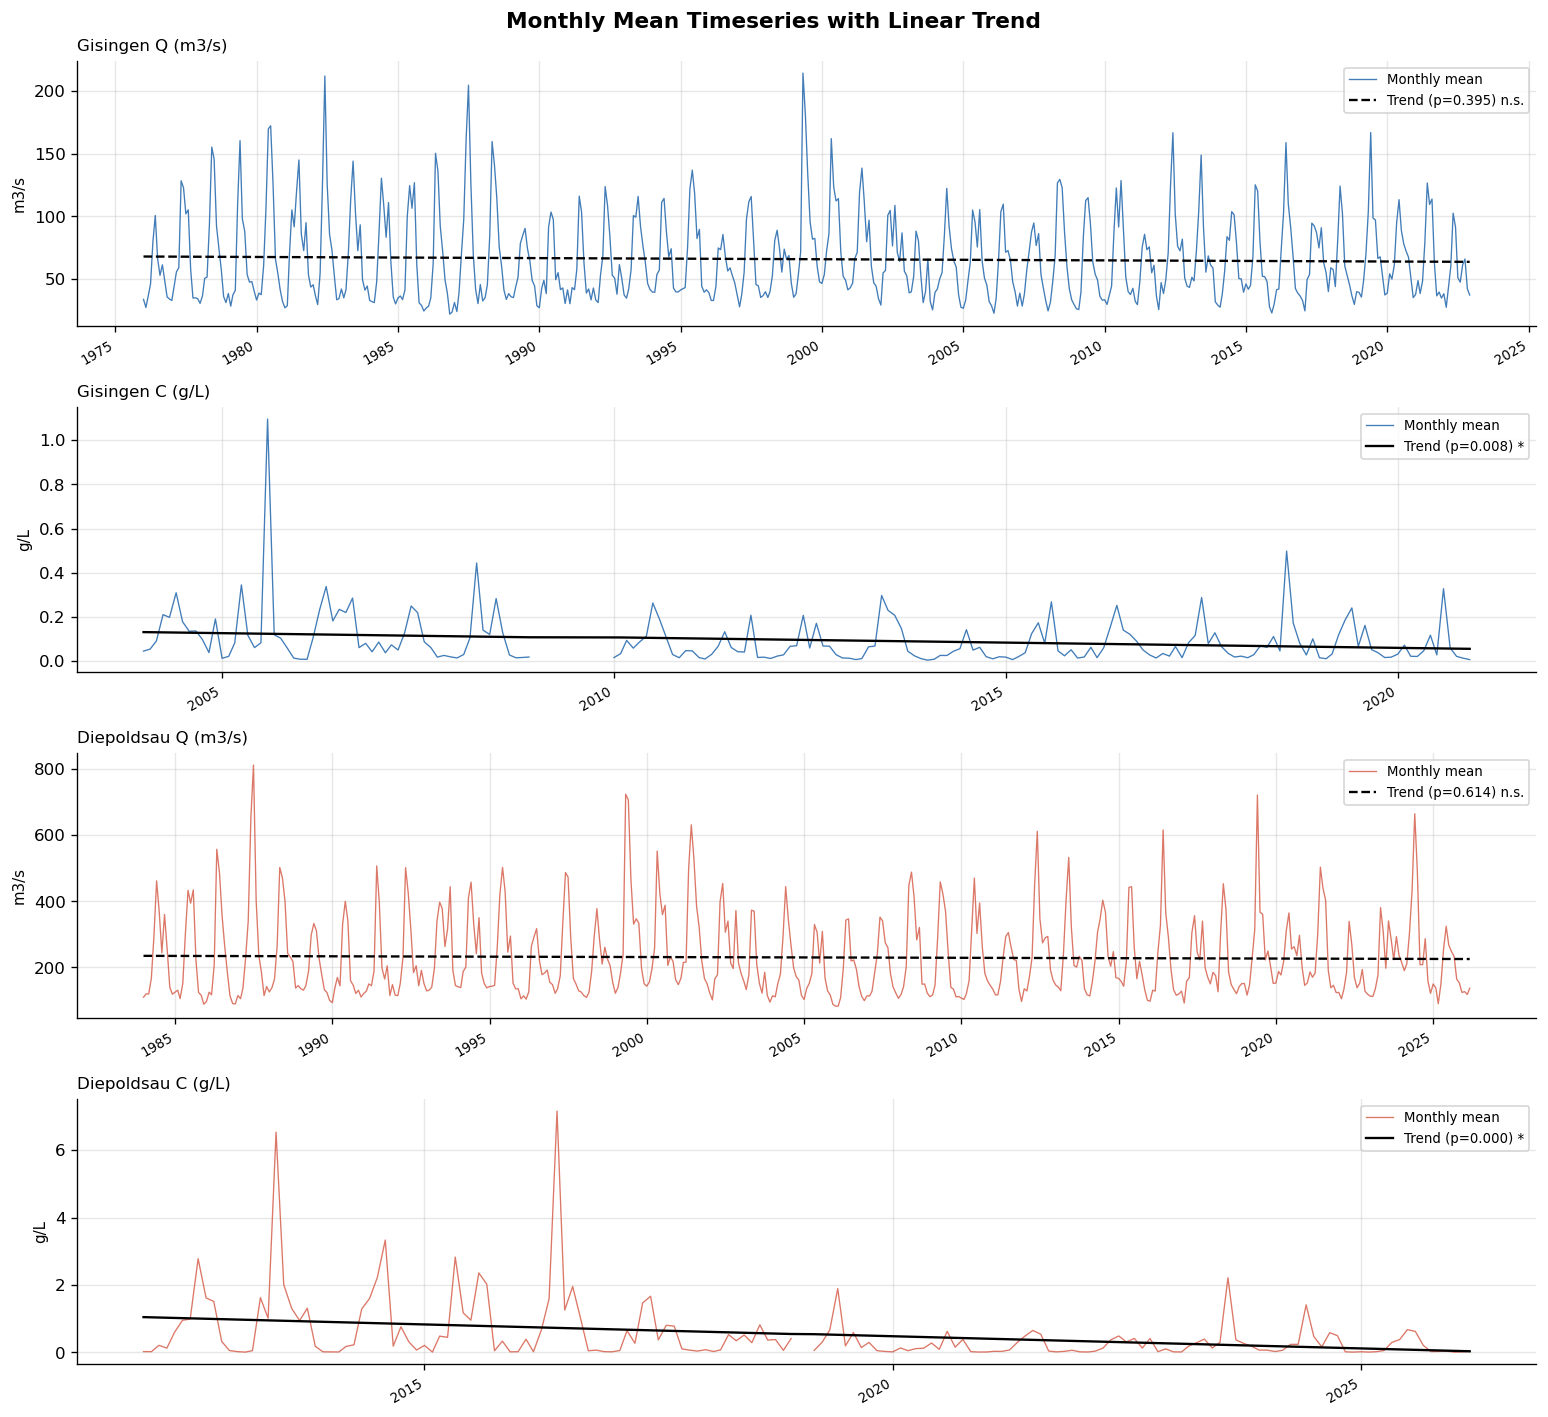

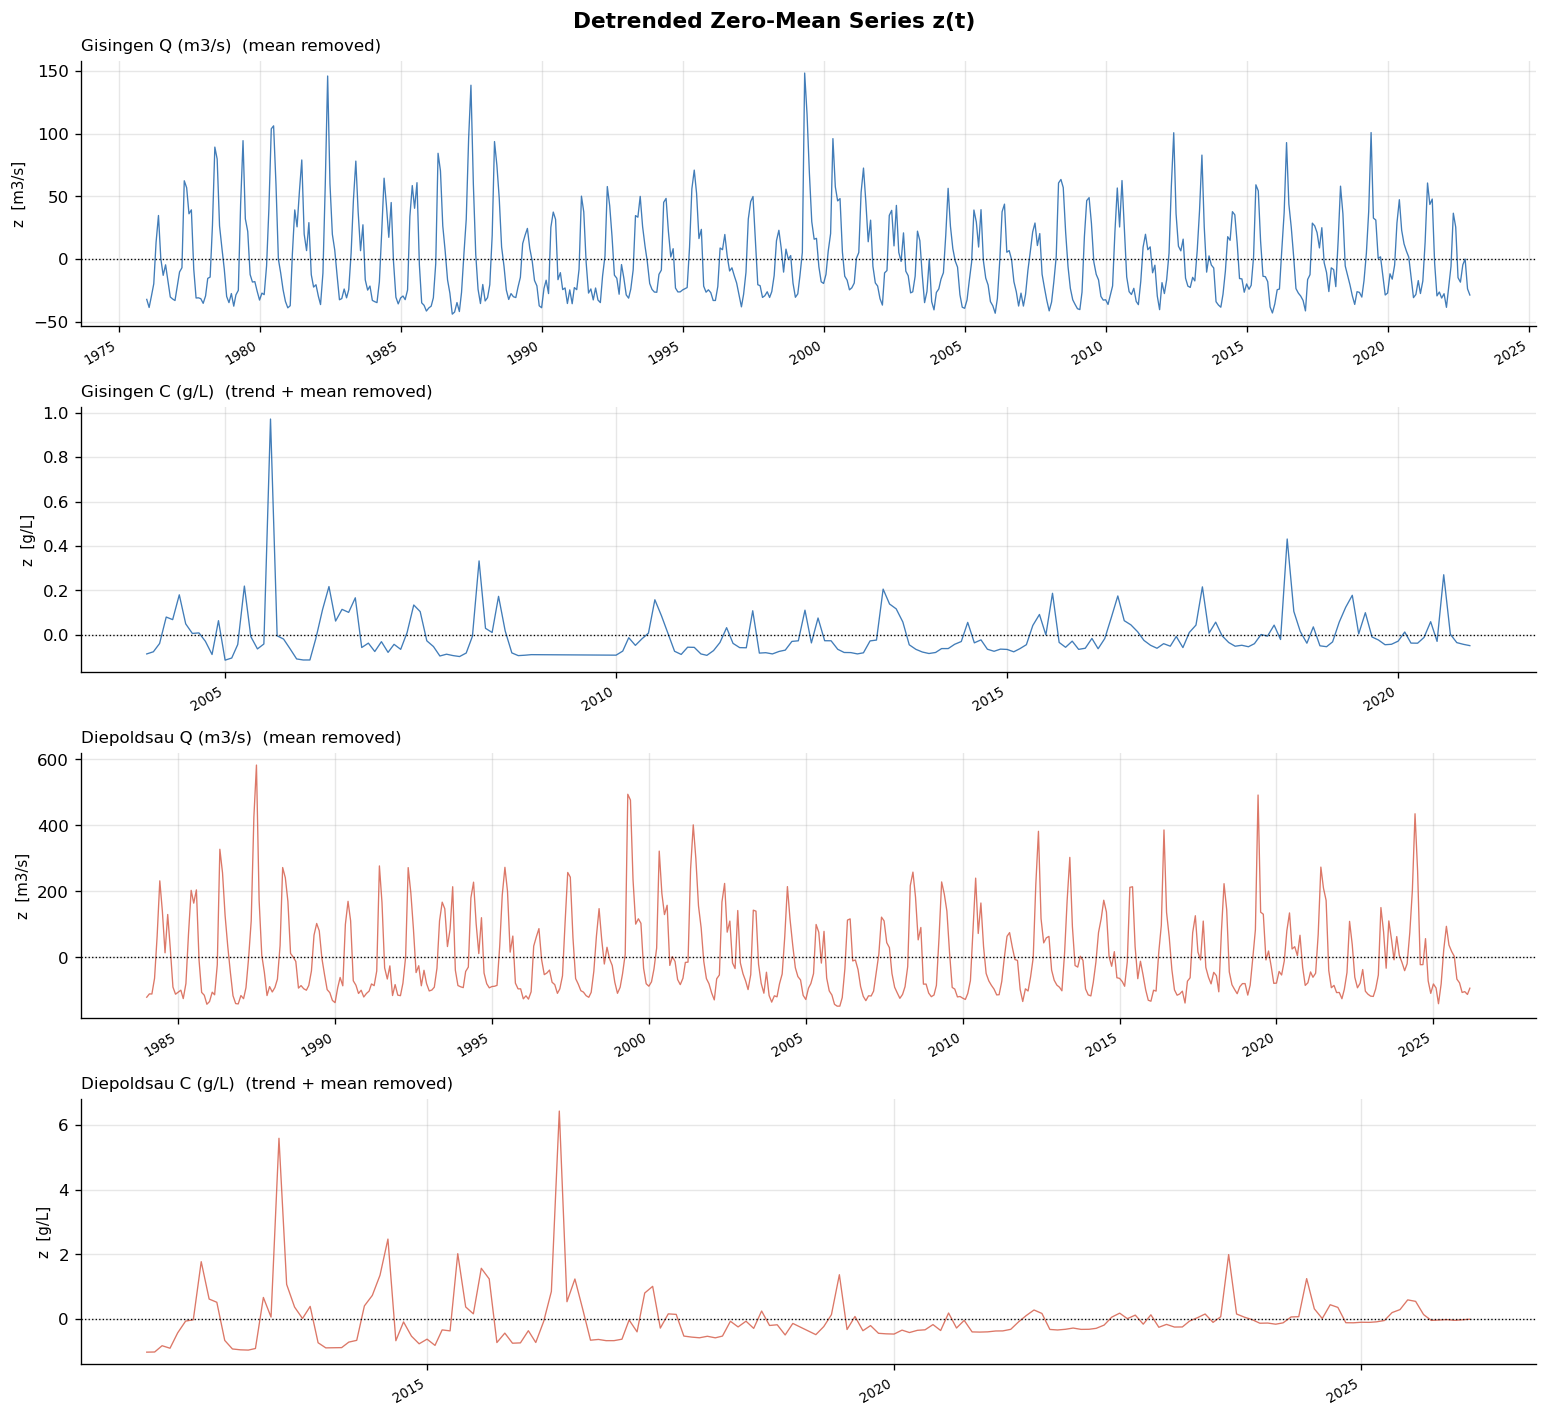

In [9]:
# Section 1 — PLOT

COLORS   = {"Gisingen": "#2166ac", "Diepoldsau": "#d6604d"}
labels   = list(monthly_series.keys())
series   = list(monthly_series.values())
units    = ["m3/s", "g/L", "m3/s", "g/L"]
stations = ["Gisingen", "Gisingen", "Diepoldsau", "Diepoldsau"]

# Figure 1: Raw monthly timeseries with trend line
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig.suptitle("Monthly Mean Timeseries with Linear Trend", fontsize=13, fontweight="bold")

for ax, label, s, unit, station in zip(axes, labels, series, units, stations):
    color = COLORS[station]
    ax.plot(s.index, s.values, color=color, linewidth=0.8, alpha=0.85, label="Monthly mean")
    tr = trends[label]
    p  = tr["p_value"]
    ls = "-" if p < 0.05 else "--"
    sig_marker = " *" if p < 0.05 else " n.s."
    lbl = f"Trend (p={p:.3f}){sig_marker}"
    ax.plot(tr["fitted"].index, tr["fitted"].values, color="k", linewidth=1.4, linestyle=ls, label=lbl)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=10, loc="left")
    ax.legend(fontsize=8, loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig1_raw_timeseries.png", bbox_inches="tight")
plt.show()

# Figure 2: Detrended zero-mean series
fig2, axes2 = plt.subplots(4, 1, figsize=(13, 12), sharex=False)
fig2.suptitle("Detrended Zero-Mean Series z(t)", fontsize=13, fontweight="bold")

for ax, label, unit, station in zip(axes2, labels, units, stations):
    color = COLORS[station]
    z     = detrended[label]
    tag   = "(trend + mean removed)" if trend_flags[label] else "(mean removed)"
    ax.plot(z.index, z.values, color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color="k", linewidth=0.8, linestyle=":")
    ax.set_title(f"{label}  {tag}", fontsize=10, loc="left")
    ax.set_ylabel(f"z  [{unit}]", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("../DATA/fig2_detrended_series.png", bbox_inches="tight")
plt.show()

In [11]:
# Section 1 — PRINT

rows = [summarise_trend(label, trends[label], alpha=0.05) for label in labels]
df_trend = pd.DataFrame(rows).set_index("Series")
print("=== Linear Trend Test Results (alpha = 5%) ===")
print(df_trend.to_string())

print("=== Zero-Mean Series: Sample Variance sigma^2_z ===")
for label in labels:
    unit = "m3/s" if "Q" in label else "g/L"
    print(f"  {label:<25s}  sigma2_z = {variances[label]:>12.4f}  [{unit}^2]")

print("=== Monthly Data Record Lengths ===")
for label, s in monthly_series.items():
    valid    = s.dropna()
    total    = len(s)
    n_valid  = len(valid)
    coverage = 100 * n_valid / total if total > 0 else 0
    print(f"  {label:<25s}  {valid.index[0].date()} to {valid.index[-1].date()}"
          f"  |  {n_valid}/{total} months valid ({coverage:.1f}%)")

=== Linear Trend Test Results (alpha = 5%) ===
                    Slope (units/month) p-value      R² Significant (5%)
Series                                                                  
Gisingen Q (m3/s)           -7.5179e-03  0.3952  0.0013               no
Gisingen C (g/L)            -3.9611e-04  0.0076  0.0369              YES
Diepoldsau Q (m3/s)         -1.9002e-02  0.6136  0.0005               no
Diepoldsau C (g/L)          -6.0277e-03  0.0000  0.0985              YES
=== Zero-Mean Series: Sample Variance sigma^2_z ===
  Gisingen Q (m3/s)          sigma2_z =    1166.3124  [m3/s^2]
  Gisingen C (g/L)           sigma2_z =       0.0127  [g/L^2]
  Diepoldsau Q (m3/s)        sigma2_z =   15335.4259  [m3/s^2]
  Diepoldsau C (g/L)         sigma2_z =       0.7961  [g/L^2]
=== Monthly Data Record Lengths ===
  Gisingen Q (m3/s)          1976-01-01 to 2022-12-01  |  564/565 months valid (99.8%)
  Gisingen C (g/L)           2004-01-01 to 2020-12-01  |  192/205 months valid (93.7%)
  D

### Section 1 — Discussion

*Fill in after running the cells above.*

**Stationarity:** Which series have a significant trend (p < 0.05)?  
**Seasonality:** Monthly data is expected to show strong seasonal oscillation — does it?  
**Discharge trend — physical or instrumental?**  
For Gisingen Q (1976–2013), a long-term increase could reflect: (a) glacier retreat raising summer baseflow, (b) changes in Illspitz Kraftwerk regulation, or (c) a rating-curve drift at the gauging station.  
**Post-detrending:** Confirm zero mean and comment on whether variance appears stable over the record.

---
## Section 2 — Timeseries Modelling
*Points: 5 | Branch: task2-modelling — to be implemented*

---
## Section 3 — Application & Evaluation
*Points: 5 | Branch: task3-evaluation — to be implemented*

---
## Section 4 — Ill to Rhein Relative Sediment Influence
*Points: 5 | Branch: task4-simulation — to be implemented*

---
## Section 5 — Independent Variables?
*Points: 3 | Branch: task5-independence — to be implemented*